In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/raw_data.csv")

df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


In [2]:
df.isnull().sum()

FL_DATE                          0
AIRLINE                          0
AIRLINE_DOT                      0
AIRLINE_CODE                     0
DOT_CODE                         0
FL_NUMBER                        0
ORIGIN                           0
ORIGIN_CITY                      0
DEST                             0
DEST_CITY                        0
CRS_DEP_TIME                     0
DEP_TIME                     77615
DEP_DELAY                    77644
TAXI_OUT                     78806
WHEELS_OFF                   78806
WHEELS_ON                    79944
TAXI_IN                      79944
CRS_ARR_TIME                     0
ARR_TIME                     79942
ARR_DELAY                    86198
CANCELLED                        0
CANCELLATION_CODE          2920860
DIVERTED                         0
CRS_ELAPSED_TIME                14
ELAPSED_TIME                 86198
AIR_TIME                     86198
DISTANCE                         0
DELAY_DUE_CARRIER          2466137
DELAY_DUE_WEATHER   

In [6]:
columns_to_drop = [
    "AIRLINE_DOT",
    "DOT_CODE",
    "FL_NUMBER"
]

df = df.drop(columns=columns_to_drop, errors="ignore")

In [7]:
df.columns

Index(['FL_DATE', 'AIRLINE', 'AIRLINE_CODE', 'ORIGIN', 'ORIGIN_CITY', 'DEST',
       'DEST_CITY', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME',
       'ARR_DELAY', 'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED',
       'CRS_ELAPSED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS',
       'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT'],
      dtype='object')

In [8]:
df = df.dropna(subset=["DEP_DELAY", "ARR_DELAY"])

In [9]:
df.shape

(2913802, 29)

In [10]:
df["FL_DATE"] = pd.to_datetime(df["FL_DATE"])

In [11]:
columns_to_remove = [
    "CANCELLATION_CODE",
    "TAXI_OUT",
    "WHEELS_OFF",
    "WHEELS_ON",
    "TAXI_IN",
    "AIR_TIME",
    "CRS_ELAPSED_TIME",
    "ELAPSED_TIME",
    "CRS_DEP_TIME",
    "CRS_ARR_TIME",
    "DEP_TIME",
    "ARR_TIME",
    "DELAY_DUE_CARRIER",
    "DELAY_DUE_WEATHER",
    "DELAY_DUE_NAS",
    "DELAY_DUE_SECURITY",
    "DELAY_DUE_LATE_AIRCRAFT"
]

df = df.drop(columns=columns_to_remove, errors="ignore")

In [12]:
df = df[[
    "FL_DATE",
    "AIRLINE",
    "ORIGIN",
    "DEST",
    "DEP_DELAY",
    "ARR_DELAY",
    "DISTANCE"
]]

In [13]:
df = df[(df["DEP_DELAY"] > -100) & (df["DEP_DELAY"] < 500)]
df = df[(df["ARR_DELAY"] > -100) & (df["ARR_DELAY"] < 500)]

In [14]:
df.to_csv("../data/processed/cleaned_data.csv", index=False)

In [15]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2909572 entries, 0 to 2999999
Data columns (total 7 columns):
 #   Column     Dtype         
---  ------     -----         
 0   FL_DATE    datetime64[ns]
 1   AIRLINE    object        
 2   ORIGIN     object        
 3   DEST       object        
 4   DEP_DELAY  float64       
 5   ARR_DELAY  float64       
 6   DISTANCE   float64       
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 177.6+ MB


In [16]:
df = df.drop(columns=["AIRLINE_CODE"], errors="ignore")

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2909572 entries, 0 to 2999999
Data columns (total 7 columns):
 #   Column     Dtype         
---  ------     -----         
 0   FL_DATE    datetime64[ns]
 1   AIRLINE    object        
 2   ORIGIN     object        
 3   DEST       object        
 4   DEP_DELAY  float64       
 5   ARR_DELAY  float64       
 6   DISTANCE   float64       
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 177.6+ MB


In [18]:
df.groupby("AIRLINE")["ARR_DELAY"].mean().sort_values(ascending=False)

AIRLINE
JetBlue Airways                       11.033596
Allegiant Air                         10.906296
Frontier Airlines Inc.                 9.707604
Spirit Air Lines                       7.038741
ExpressJet Airlines LLC d/b/a aha!     6.813349
Mesa Airlines Inc.                     5.129584
American Airlines Inc.                 4.321450
United Air Lines Inc.                  3.894780
Southwest Airlines Co.                 3.254948
Hawaiian Airlines Inc.                 3.237302
PSA Airlines Inc.                      3.163059
Envoy Air                              2.471888
Horizon Air                            2.314109
SkyWest Airlines Inc.                  1.754189
Alaska Airlines Inc.                   1.000855
Delta Air Lines Inc.                  -0.121730
Republic Airline                      -0.187364
Endeavor Air Inc.                     -2.421602
Name: ARR_DELAY, dtype: float64

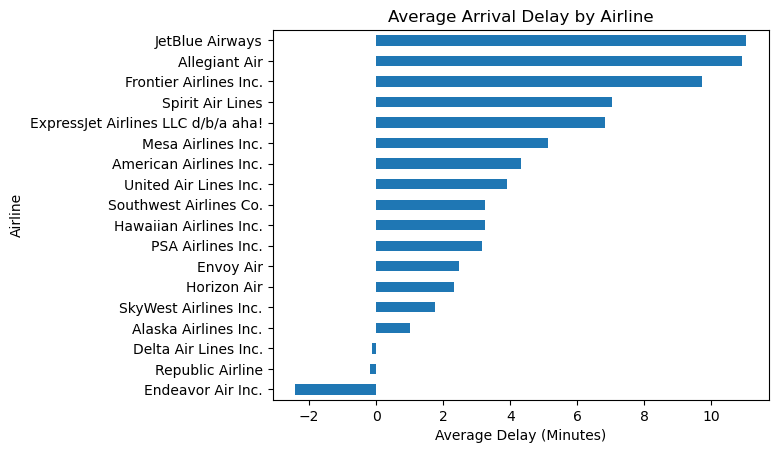

In [19]:
import matplotlib.pyplot as plt

avg_delay = df.groupby("AIRLINE")["ARR_DELAY"].mean().sort_values()

plt.figure()
avg_delay.plot(kind="barh")
plt.title("Average Arrival Delay by Airline")
plt.xlabel("Average Delay (Minutes)")
plt.ylabel("Airline")
plt.show()

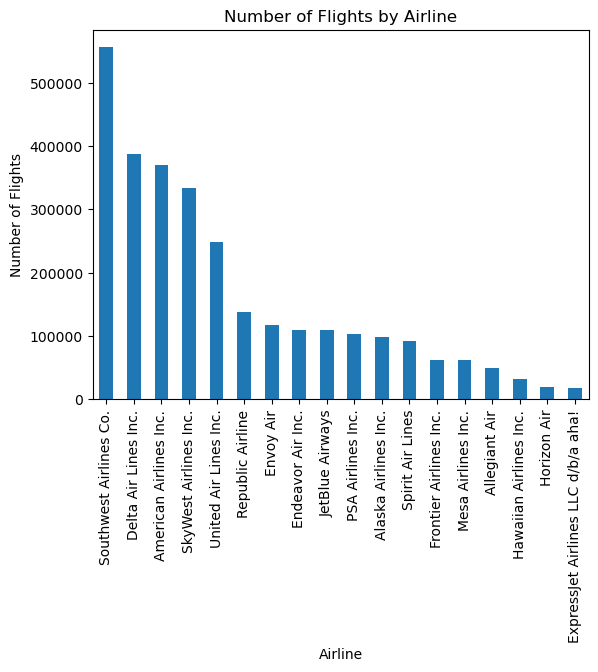

In [20]:
df["AIRLINE"].value_counts().plot(kind="bar")
plt.title("Number of Flights by Airline")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")
plt.show()

In [21]:
df["AIRLINE"] = df["AIRLINE"].str.replace("Inc.", "", regex=False)
df["AIRLINE"] = df["AIRLINE"].str.replace("LLC", "", regex=False)
df["AIRLINE"] = df["AIRLINE"].str.replace("d/b/a aha!", "", regex=False)
df["AIRLINE"] = df["AIRLINE"].str.strip()

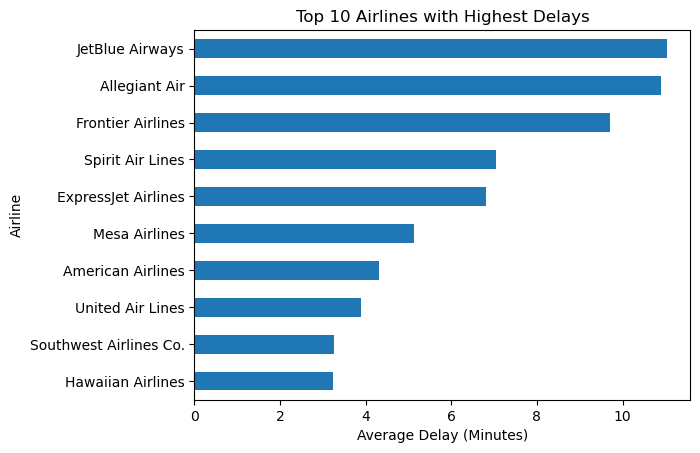

In [22]:
avg_delay = df.groupby("AIRLINE")["ARR_DELAY"].mean().sort_values()

avg_delay.tail(10).plot(kind="barh")
plt.title("Top 10 Airlines with Highest Delays")
plt.xlabel("Average Delay (Minutes)")
plt.ylabel("Airline")
plt.show()

In [23]:
df["ROUTE"] = df["ORIGIN"] + " → " + df["DEST"]

df.groupby("ROUTE")["ARR_DELAY"].mean().sort_values(ascending=False).head(10)

ROUTE
CHA → MSP    206.000000
VPS → STC    198.000000
GRB → FLL    160.000000
KOA → BLI    149.000000
SAN → AZA    123.333333
MSY → GSP    120.000000
GSP → TPA    117.750000
SGU → AZA    114.200000
FLL → ATW    107.375000
TWF → SFO    103.500000
Name: ARR_DELAY, dtype: float64

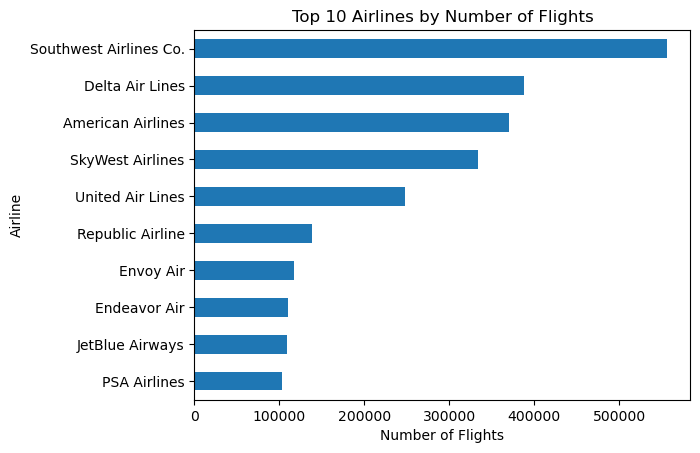

In [24]:
# Visual 2: Number of Flights by Airline

flight_counts = df["AIRLINE"].value_counts().head(10)

plt.figure()
flight_counts.sort_values().plot(kind="barh")
plt.title("Top 10 Airlines by Number of Flights")
plt.xlabel("Number of Flights")
plt.ylabel("Airline")
plt.show()

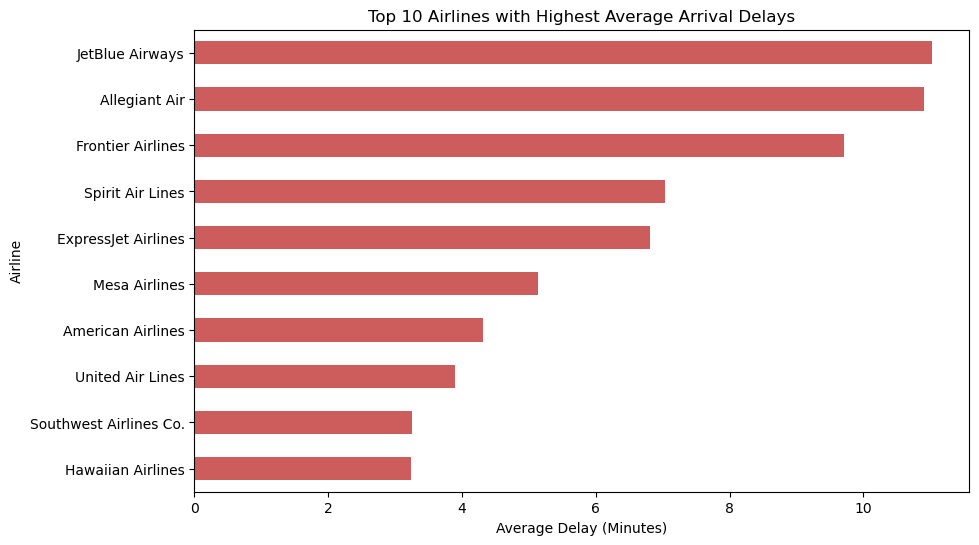

In [37]:
plt.figure(figsize=(10,6))

avg_delay.tail(10).plot(kind="barh", color="indianred")

plt.title("Top 10 Airlines with Highest Average Arrival Delays")
plt.xlabel("Average Delay (Minutes)")
plt.ylabel("Airline")

plt.savefig("../images/airline_delay.png", bbox_inches="tight")
plt.show()

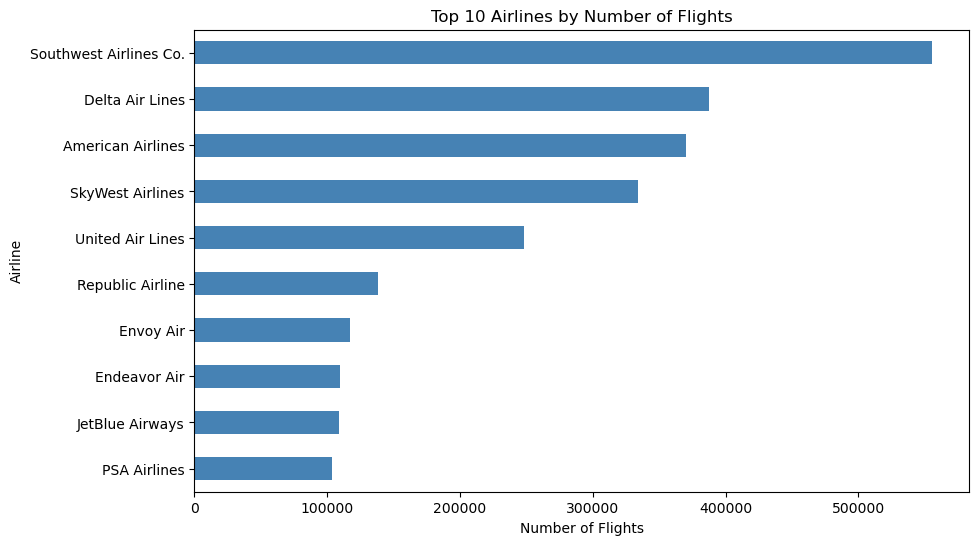

In [38]:
plt.figure(figsize=(10,6))

flight_counts.sort_values().plot(kind="barh", color="steelblue")

plt.title("Top 10 Airlines by Number of Flights")
plt.xlabel("Number of Flights")
plt.ylabel("Airline")

plt.savefig("../images/flight_count.png", bbox_inches="tight")
plt.show()

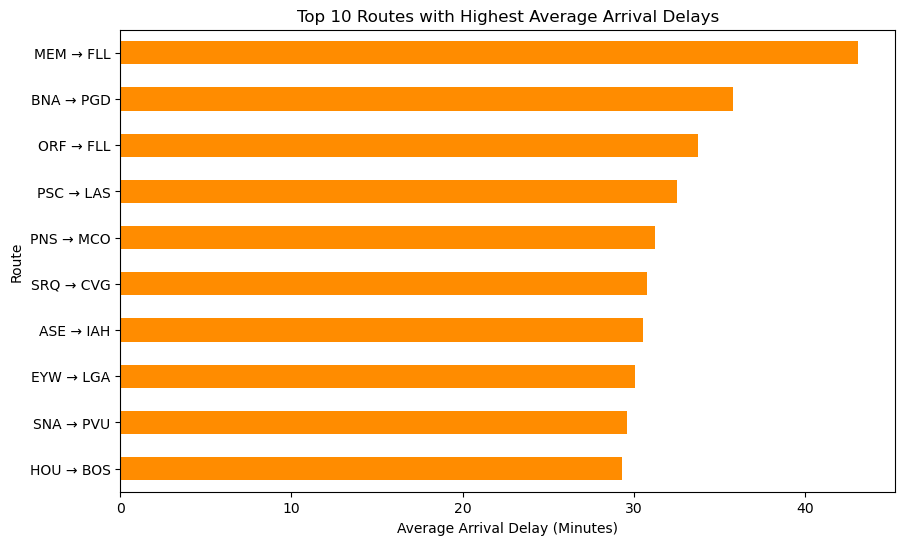

In [39]:
plt.figure(figsize=(10,6))

route_delay.sort_values().plot(kind="barh", color="darkorange")

plt.title("Top 10 Routes with Highest Average Arrival Delays")
plt.xlabel("Average Arrival Delay (Minutes)")
plt.ylabel("Route")

plt.savefig("../images/route_delay.png", bbox_inches="tight")
plt.show()

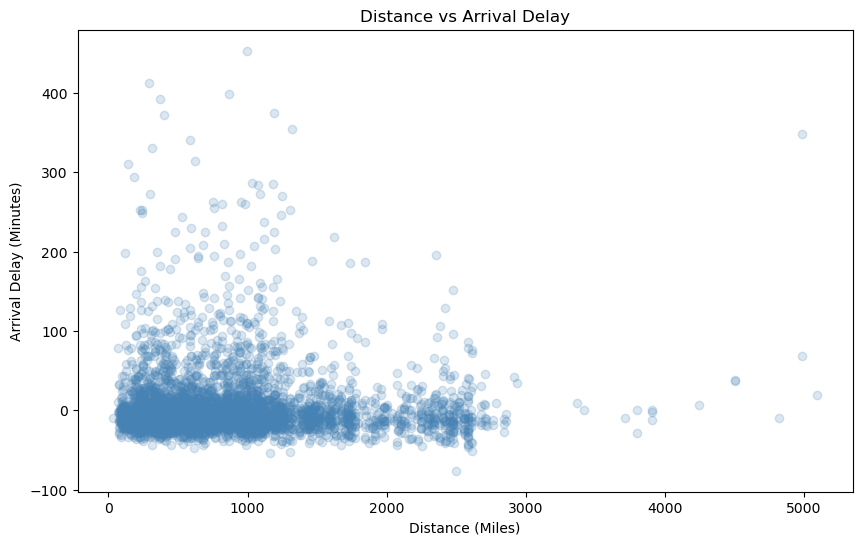

In [40]:
plt.figure(figsize=(10,6))

plt.scatter(sample_df["DISTANCE"], sample_df["ARR_DELAY"], alpha=0.2, color="steelblue")

plt.title("Distance vs Arrival Delay")
plt.xlabel("Distance (Miles)")
plt.ylabel("Arrival Delay (Minutes)")

plt.savefig("../images/distance_vs_delay.png", bbox_inches="tight")
plt.show()

In [41]:
# Save summary tables
avg_delay.to_csv("../outputs/avg_delay_by_airline.csv")
route_delay.to_csv("../outputs/top_delayed_routes.csv")

In [46]:
data_cleaning_code = '''
"""
Clean raw flight delay data and save a processed dataset.
"""

import pandas as pd


def clean_flight_data():
    df = pd.read_csv("../data/raw/raw_data.csv")

    columns_to_drop = [
        "AIRLINE_DOT", "DOT_CODE", "FL_NUMBER", "CANCELLATION_CODE",
        "TAXI_OUT", "WHEELS_OFF", "WHEELS_ON", "TAXI_IN", "AIR_TIME",
        "CRS_ELAPSED_TIME", "ELAPSED_TIME", "CRS_DEP_TIME", "CRS_ARR_TIME",
        "DEP_TIME", "ARR_TIME", "DELAY_DUE_CARRIER", "DELAY_DUE_WEATHER",
        "DELAY_DUE_NAS", "DELAY_DUE_SECURITY", "DELAY_DUE_LATE_AIRCRAFT",
        "AIRLINE_CODE"
    ]

    df = df.drop(columns=columns_to_drop, errors="ignore")
    df = df.dropna(subset=["DEP_DELAY", "ARR_DELAY"])
    df["FL_DATE"] = pd.to_datetime(df["FL_DATE"])

    df = df[["FL_DATE", "AIRLINE", "ORIGIN", "DEST", "DEP_DELAY", "ARR_DELAY", "DISTANCE"]]

    df = df[(df["DEP_DELAY"] > -100) & (df["DEP_DELAY"] < 500)]
    df = df[(df["ARR_DELAY"] > -100) & (df["ARR_DELAY"] < 500)]

    df["AIRLINE"] = df["AIRLINE"].str.replace("Inc.", "", regex=False)
    df["AIRLINE"] = df["AIRLINE"].str.replace("LLC", "", regex=False)
    df["AIRLINE"] = df["AIRLINE"].str.replace("d/b/a aha!", "", regex=False)
    df["AIRLINE"] = df["AIRLINE"].str.strip()

    df.to_csv("../data/processed/cleaned_data.csv", index=False)

    print("Cleaned data saved to data/processed/cleaned_data.csv")


if __name__ == "__main__":
    clean_flight_data()
'''

with open("../scripts/data_cleaning.py", "w", encoding="utf-8") as file:
    file.write(data_cleaning_code)

print("data_cleaning.py created successfully.")

data_cleaning.py created successfully.


In [47]:
analysis_code = '''
"""
Analyze cleaned flight delay data and export summary results.
"""

import pandas as pd


def analyze_flight_data():
    df = pd.read_csv("../data/processed/cleaned_data.csv")

    df["ROUTE"] = df["ORIGIN"] + " → " + df["DEST"]

    avg_delay = df.groupby("AIRLINE")["ARR_DELAY"].mean().sort_values(ascending=False)

    route_counts = df["ROUTE"].value_counts()
    valid_routes = route_counts[route_counts > 50].index
    filtered_df = df[df["ROUTE"].isin(valid_routes)]

    route_delay = (
        filtered_df.groupby("ROUTE")["ARR_DELAY"]
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )

    avg_delay.to_csv("../outputs/avg_delay_by_airline.csv")
    route_delay.to_csv("../outputs/top_delayed_routes.csv")

    print("Analysis outputs saved to outputs folder.")
    print("\\nAverage delay by airline:")
    print(avg_delay.head())

    print("\\nTop delayed routes:")
    print(route_delay.head())


if __name__ == "__main__":
    analyze_flight_data()
'''

with open("../scripts/analysis.py", "w", encoding="utf-8") as file:
    file.write(analysis_code)

print("analysis.py created successfully.")

analysis.py created successfully.


In [50]:
df = pd.read_csv("../data/processed/cleaned_data.csv")

df_sample = df.head(100)

df_sample.to_csv("../data/processed/cleaned_data_sample.csv", index=False)
df_sample.to_excel("../data/processed/cleaned_data_sample.xlsx", index=False)